In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
from scipy import stats as st

In [2]:
df_01 = pd.read_csv("datasets/moved_project_sql_result_01.csv")
df_04 = pd.read_csv("datasets/moved_project_sql_result_04.csv")

In [3]:
df_04.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


Focaremos nos 10 principais bairros para identificar os hub's que possuem maior demanda

In [4]:
df_04.sort_values(by="average_trips", ascending=False).head(10)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


In [5]:
df_04.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


<AxesSubplot:xlabel='average_trips', ylabel='dropoff_location_name'>

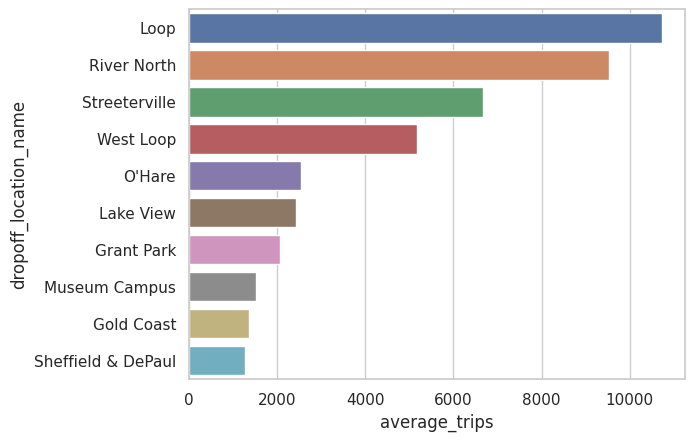

In [6]:
top_10_dropoff_locations = df_04.sort_values(by="average_trips", ascending=False).head(10)
sns.set_theme(style="whitegrid")
sns.barplot(data= top_10_dropoff_locations, x="average_trips", y="dropoff_location_name")

A média de viagens pode indicar que existam centros de gravidade (hubs como aeroportos ou centros financeiros) massivos na cidade, localizados nas regiões com um alto volume de viagens, devido a discrepância dos dados em comparação do primeiro para o decimo colocado

In [7]:
df_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


<AxesSubplot:xlabel='trips_amount', ylabel='company_name'>

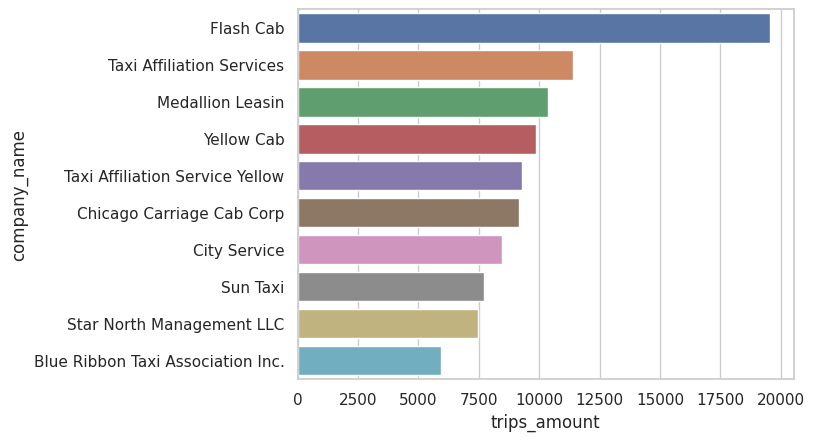

In [8]:
top_10_companies = df_01.sort_values(by="trips_amount", ascending=False).head(10)
sns.set_theme(style="whitegrid")
sns.barplot(data= top_10_companies, x="trips_amount", y="company_name")

Com a liderança avançada da Flash Cab, pode-se assumir que a empresa possui uma infraestrutura superior ou uma exclusividade de atuação em pontos de fluxos altos, como Loop, River North ou StreeterVille

1. Hipótese Nula ($H_0$): A duração média das viagens do Loop para o Aeroporto O'Hare é a mesma nos sábados chuvosos e nos sábados de sol. 
2. Hipótese Alternativa ($H_1$): A duração média das viagens muda (é diferente) dependendo das condições climáticas nos sábados.

In [9]:
df_07 = pd.read_csv("datasets/moved_project_sql_result_07.csv")

In [10]:
df_07.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [11]:
good_weather_duration = df_07[df_07['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_duration = df_07[df_07['weather_conditions'] == 'Bad']['duration_seconds']

In [12]:
print(f"Variância (Clima Bom): {good_weather_duration.var():.2f}")
print(f"Variância (Clima Ruim): {bad_weather_duration.var():.2f}")

Variância (Clima Bom): 576382.01
Variância (Clima Ruim): 520294.09


Antes de aplicar o Teste t de Student para comparar as médias, é fundamental verificar a homocedasticidade (igualdade de variâncias)

p-value > 0,05: As variâncias são iguais (homocedasticidade). Você pode usar o Teste t padrão (equal_var=True).

In [13]:
levene_results = st.levene(good_weather_duration, bad_weather_duration)
print('p-value do Teste de Levene:', levene_results.pvalue)

alpha = 0.05
if levene_results.pvalue < alpha:
    print("Variâncias são diferentes (Use equal_var=False)")
else:
    print("Variâncias são semelhantes (Use equal_var=True)")

p-value do Teste de Levene: 0.5332038671974493
Variâncias são semelhantes (Use equal_var=True)


In [ ]:
alpha = 0.05

results = st.ttest_ind(good_weather_duration, bad_weather_duration, equal_var=levene_results.pvalue < alpha)

print('p-value do teste t:', results.pvalue)

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula: a duração média muda significativamente.")
else:
    print("Não podemos rejeitar a hipótese nula: não há diferença significativa.")

p-value do teste t: 6.517970327099473e-12
Rejeitamos a hipótese nula: a duração média muda significativamente.


Com base no valor do teste t, o clima chuvoso impacta o deslocamento entre o loop e o Aeroporto O'Hare